# Importing

In [13]:
import spacy
import pandas as pd
from spacy_layout import spaCyLayout
from dataclasses import dataclass
import matplotlib.pyplot as plt

# Processing a Document

In [14]:
# Create a blank spaCy Pipeline for English
nlp = spacy.load("en_core_web_lg")

In [15]:
# Create an instance of the spaCyLayout pipeline
def display_table(df: pd.DataFrame) -> str:
    lines = []

    # Header
    lines.append(" | ".join(map(str, df.columns)))

    # Rows
    for _, row in df.iterrows():
        values = [
            str(v).strip()
            for v in row
            if pd.notna(v) and str(v).strip()
        ]
        lines.append(" | ".join(values))

    return "\n".join(lines)


layout = spaCyLayout(nlp, display_table=display_table)

In [16]:
# Process a document and create a spaCy Doc object
doc = layout(r"cv reference.pdf")
print(doc)

2026-06-29 12:36:19,519 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2026-06-29 12:36:19,519 - INFO - Going to convert document batch...
2026-06-29 12:36:19,519 - INFO - Initializing pipeline for StandardPdfPipeline with options hash e647edf348883bed75367b22fbe60347
2026-06-29 12:36:19,526 - INFO - Accelerator device: 'cpu'
2026-06-29 12:36:22,409 - INFO - Accelerator device: 'cpu'
2026-06-29 12:36:53,330 - INFO - Accelerator device: 'cpu'
2026-06-29 12:36:54,028 - INFO - Processing document cv reference.pdf
2026-06-29 12:37:02,040 - INFO - Finished converting document cv reference.pdf in 42.53 sec.


l

M UHAMMAD E NRIZKY B RILLIAN

billy.suharno@mail.utoronto.ca | linkedin.com/in/enrizky-brillian/ | portfolio

SUMMARY OF QUALIFICATIONS

l Frameworks: NumPy, Pandas, Scikit-Learn, PyTorch, TensorFlow, Keras, Google GenAI, LangChain, Hugging Face, PySpark, Jupyter Notebook, Linux, Git, React, TypeScript, R Language, tidyverse, SQL, AWS, GCP.

l ML & DL Techniques: Neural Network, RAG, Multi-Agents, Transformers, Principal Component Analysis, KNN/Logistic/Multinomial Regression, Random Forest, AdaBoost, Support Vector Machine, Clustering.

RELEVANT EXPERIENCES

Machine Learning Developer

IBM (International Business Machine), Toronto, ON

l Engineered end -to -end, multi -agent Text -to -SQL solution within AWS environment, utilizing App Runner, VPC, ECR, Bedrock, OpenSearch, and Redis, to achieve 93% accuracy in 8 weeks for over $300K contract .

l Developed cross-platform UI using React with TypeScript for web deployment, and React Native with Expo for mobile applications, enabling 

# Parser


In [17]:


@dataclass
class LayoutBlock:
    text: str
    label: str
    heading: str | None
    x: float
    y: float
    width: float
    height: float
    page: int

In [18]:
blocks = []

for span in doc.spans["layout"]:
    layout = span._.layout

    blocks.append(
        LayoutBlock(
            text=span.text.strip(),
            label=span.label_,
            heading=span._.heading,
            x=layout.x,
            y=layout.y,
            width=layout.width,
            height=layout.height,
            page=layout.page_no,
        )
    )


# ** Table detection left **

blocks.sort(key=lambda b: (b.page, b.y, b.x))


for i in blocks:
    print(i)

LayoutBlock(text='M UHAMMAD E NRIZKY B RILLIAN', label='section_header', heading=None, x=199.422, y=32.710000000000036, width=243.105, height=14.132999999999925, page=1)
LayoutBlock(text='billy.suharno@mail.utoronto.ca | linkedin.com/in/enrizky-brillian/ | portfolio', label='text', heading=M UHAMMAD E NRIZKY B RILLIAN, x=146.315, y=58.05600000000004, width=349.338, height=9.870000000000005, page=1)
LayoutBlock(text='SUMMARY OF QUALIFICATIONS', label='section_header', heading=None, x=53.76, y=76.21400000000006, width=196.364, height=9.702999999999975, page=1)
LayoutBlock(text='l Frameworks: NumPy, Pandas, Scikit-Learn, PyTorch, TensorFlow, Keras, Google GenAI, LangChain, Hugging Face, PySpark, Jupyter Notebook, Linux, Git, React, TypeScript, R Language, tidyverse, SQL, AWS, GCP.', label='list_item', heading=SUMMARY OF QUALIFICATIONS, x=29.76, y=95.269, width=562.054, height=25.54200000000003, page=1)
LayoutBlock(text='l ML & DL Techniques: Neural Network, RAG, Multi-Agents, Transformers

Multi column detection

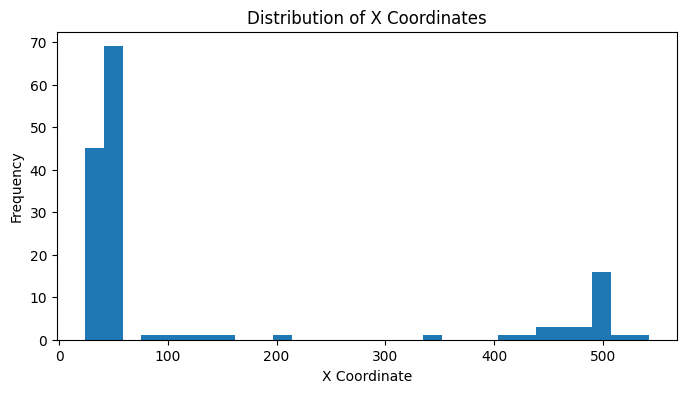

In [19]:

xs = [b.x for b in blocks]

plt.figure(figsize=(8, 4))
plt.hist(xs, bins=30)
plt.xlabel("X Coordinate")
plt.ylabel("Frequency")
plt.title("Distribution of X Coordinates")
plt.show()

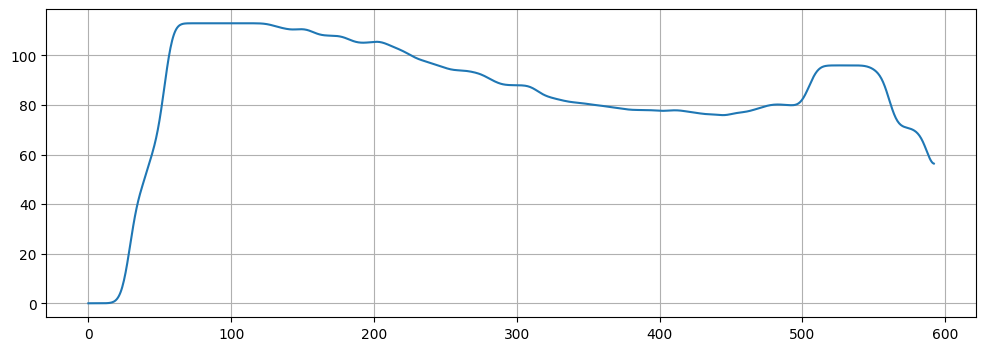

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -------------------------------------------------
# Estimate page width
# -------------------------------------------------

page_width = max(
    b.x + b.width
    for b in blocks
)

resolution = 1000

profile = np.zeros(resolution)

scale = resolution / page_width

# -------------------------------------------------
# Paint each block
# -------------------------------------------------

for b in blocks:

    start = int(b.x * scale)
    end = int((b.x + b.width) * scale)

    profile[start:end] += 1


profile = gaussian_filter1d(profile, sigma=8)

plt.figure(figsize=(12, 4))

x = np.linspace(0, page_width, resolution)

plt.plot(x, profile)

plt.grid(True)

plt.show()

In [21]:
from scipy.ndimage import gaussian_filter1d

profile = gaussian_filter1d(profile, sigma=8)

In [22]:
from scipy.signal import find_peaks

valleys, _ = find_peaks(
    -profile,
    prominence=profile.max()*0.2
)

print(valleys)


if len(valleys) > 0:
    best = valleys[
        np.argmin(profile[valleys])
    ]

    split_x = x[best]

    print(split_x)

# if this is true and detects multi then pass resume to llm with coridantes and ask to retuen strcutured cordiantes :

[]


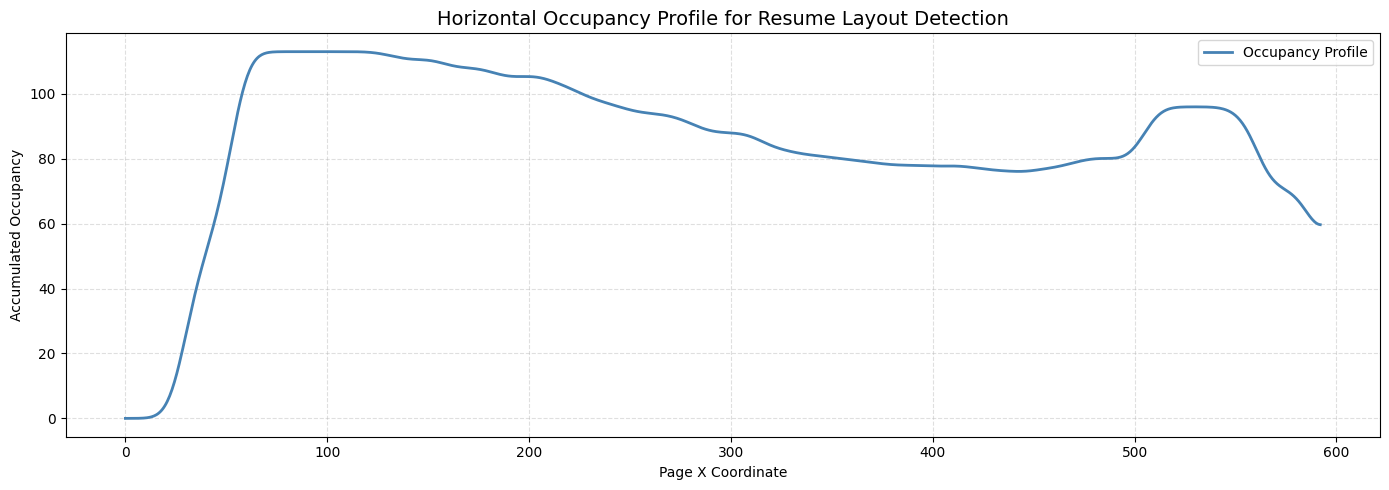

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Occupancy profile
plt.plot(
    x,
    profile,
    linewidth=2,
    color="steelblue",
    label="Occupancy Profile"
)

# Mark valleys
if len(valleys) > 0:
    plt.scatter(
        x[valleys],
        profile[valleys],
        color="red",
        s=80,
        zorder=5,
        label="Candidate Valleys"
    )

# Mark selected split
if len(valleys) > 0:
    plt.axvline(
        split_x,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Chosen Split (x={split_x:.1f})"
    )

# Shade left/right regions
if len(valleys) > 0:
    plt.axvspan(
        x.min(),
        split_x,
        color="cornflowerblue",
        alpha=0.08
    )

    plt.axvspan(
        split_x,
        x.max(),
        color="orange",
        alpha=0.08
    )

# Cosmetics
plt.title("Horizontal Occupancy Profile for Resume Layout Detection", fontsize=14)
plt.xlabel("Page X Coordinate")
plt.ylabel("Accumulated Occupancy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.show()

Extra: multi colum split using kde

In [24]:
if len(valleys) > 0:
    from sklearn.cluster import KMeans
    import numpy as np

    # Use block centers instead of left edges
    X = np.array([
        [b.x + b.width / 2]
        for b in blocks
    ])

    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    # Order left/right
    centers = kmeans.cluster_centers_.flatten()
    order = np.argsort(centers)

    mapping = {
        order[0]: 0,   # left
        order[1]: 1    # right
    }

    labels = np.array([mapping[l] for l in labels])

    left_column = []
    right_column = []

    for block, label in zip(blocks, labels):

        if label == 0:
            left_column.append(block)
        else:
            right_column.append(block)

    left_column.sort(key=lambda b: (b.page, b.y))
    right_column.sort(key=lambda b: (b.page, b.y))

    # print(left_column)
    # blocks = right_column.append(left_column)
    # for i in left_column:
    #     print(i.text)

    # print()
    blocks = right_column + left_column
    # for i in right_column:
    #     print(i)
    print(blocks)
    # print(total)

In [25]:
 print(blocks)

[LayoutBlock(text='M UHAMMAD E NRIZKY B RILLIAN', label='section_header', heading=None, x=199.422, y=32.710000000000036, width=243.105, height=14.132999999999925, page=1), LayoutBlock(text='billy.suharno@mail.utoronto.ca | linkedin.com/in/enrizky-brillian/ | portfolio', label='text', heading=M UHAMMAD E NRIZKY B RILLIAN, x=146.315, y=58.05600000000004, width=349.338, height=9.870000000000005, page=1), LayoutBlock(text='SUMMARY OF QUALIFICATIONS', label='section_header', heading=None, x=53.76, y=76.21400000000006, width=196.364, height=9.702999999999975, page=1), LayoutBlock(text='l Frameworks: NumPy, Pandas, Scikit-Learn, PyTorch, TensorFlow, Keras, Google GenAI, LangChain, Hugging Face, PySpark, Jupyter Notebook, Linux, Git, React, TypeScript, R Language, tidyverse, SQL, AWS, GCP.', label='list_item', heading=SUMMARY OF QUALIFICATIONS, x=29.76, y=95.269, width=562.054, height=25.54200000000003, page=1), LayoutBlock(text='l ML & DL Techniques: Neural Network, RAG, Multi-Agents, Transfo

NER REGEX

In [26]:
nlp1 = spacy.load("en_core_web_trf")


def extract_name(blocks, nlp1):

    for block in blocks:

        doc = nlp1(block.text)

        person = next(
            (ent.text for ent in doc.ents if ent.label_ == "PERSON"),
            None
        )

        if person:
            return person

    return None


print(blocks)
name = extract_name(blocks, nlp1)

print(name)

[LayoutBlock(text='M UHAMMAD E NRIZKY B RILLIAN', label='section_header', heading=None, x=199.422, y=32.710000000000036, width=243.105, height=14.132999999999925, page=1), LayoutBlock(text='billy.suharno@mail.utoronto.ca | linkedin.com/in/enrizky-brillian/ | portfolio', label='text', heading=M UHAMMAD E NRIZKY B RILLIAN, x=146.315, y=58.05600000000004, width=349.338, height=9.870000000000005, page=1), LayoutBlock(text='SUMMARY OF QUALIFICATIONS', label='section_header', heading=None, x=53.76, y=76.21400000000006, width=196.364, height=9.702999999999975, page=1), LayoutBlock(text='l Frameworks: NumPy, Pandas, Scikit-Learn, PyTorch, TensorFlow, Keras, Google GenAI, LangChain, Hugging Face, PySpark, Jupyter Notebook, Linux, Git, React, TypeScript, R Language, tidyverse, SQL, AWS, GCP.', label='list_item', heading=SUMMARY OF QUALIFICATIONS, x=29.76, y=95.269, width=562.054, height=25.54200000000003, page=1), LayoutBlock(text='l ML & DL Techniques: Neural Network, RAG, Multi-Agents, Transfo

skillner

In [27]:


from skillNer.general_params import SKILL_DB
from skillNer.skill_extractor_class import SkillExtractor
import regex as re
from spacy.matcher import PhraseMatcher


skill_extractor = SkillExtractor(nlp, SKILL_DB, PhraseMatcher)

loading full_matcher ...
loading abv_matcher ...
loading full_uni_matcher ...
loading low_form_matcher ...
loading token_matcher ...


In [28]:
# !pip install skillNer

import re
import unicodedata


def preprocess_resume_text(text):
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)  # remove emails
    text = re.sub(r'http\S+|www\S+', ' ', text)  # remove URLs
    text = re.sub(r'\s+', ' ', text)  # normalize spaces
    return text.strip()


def extract_skills(skill_extractor, clean_text, threshold=0.9):
    # clean_text = preprocess_resume_text(text)
    """Extract skills and categorize them into full and high-confidence partial matches."""
    annotations = skill_extractor.annotate(clean_text)
    print(annotations)
    full_matches = [skill['doc_node_value']
                    for skill in annotations["results"].get("full_matches", [])]
    # print(full_matches)
    partial_matches = [
        skill['doc_node_value']
        for skill in annotations["results"].get("ngram_scored", [])
        # Only include high-confidence matches
        if skill.get('score', 0) >= threshold
    ]
    # print(partial_matches)
    # print(full_matches,partial_matches)

    BLACKLIST = {"com", "www", "e"}

    # Combine both lists and convert to lowercase for uniformity
    all_skills = set(full_matches + partial_matches)  # Remove duplicates
    # print(all_skills)
    # Filtered skills list
    final_skills = [skill.title() for skill in all_skills if skill.lower()
                    not in BLACKLIST]

    return sorted(set(full_matches))  # Return sorted list for consistency


data = []
for i in blocks:
    data.append(i.text)
data

result = "\n".join(data)
# print(result)
result = preprocess_resume_text(result)

print(len(result))


def preprocess_resume_text(text):
    """
    Clean resume text before SkillNER extraction.
    """

    # Normalize Unicode (e.g. 𝟑 -> 3, full-width chars -> ASCII)
    text = unicodedata.normalize("NFKC", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+\.\S+", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove phone numbers
    text = re.sub(
        r"\+?\d[\d\s().-]{7,}\d",
        " ",
        text
    )

    # Replace common PDF/OCR artifacts
    replacements = {
        "Ð": "-",
        "–": "-",
        "—": "-",
        "−": "-",
        "•": " ",
        "▪": " ",
        "►": " ",
        "◆": " ",
        "■": " ",
        "●": " ",
        "○": " ",
        "·": " ",
        "\u00A0": " ",  # non-breaking space
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    # Remove remaining non-printable characters
    text = "".join(
        ch
        for ch in text
        if unicodedata.category(ch)[0] != "C"
    )

    # Collapse whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# **only process 10,000
# # print(result[14300:])
# print(len(preprocess_resume_text(result[10000:])))
# print(extract_skills(skill_extractor, preprocess_resume_text(result[:10005])))

14430


sectioning for LLM

In [29]:
TARGET_SECTIONS = {
    "education": [],
    "experience": [],
    "projects": [],
    "certifications": [],
    "publications": [],
    "references": []
}

In [48]:
from rapidfuzz import process, fuzz

# -------------------------------------------------------
# Canonical Resume Sections
# -------------------------------------------------------

CANONICAL_SECTIONS = {

    "summary": [
        "SUMMARY",
        "PROFESSIONAL SUMMARY",
        "CAREER SUMMARY",
        "PROFILE",
        "PROFESSIONAL PROFILE",
        "EXECUTIVE SUMMARY",
        "ABOUT ME",
        "ABOUT",
        "OBJECTIVE",
        "CAREER OBJECTIVE",
        "PROFESSIONAL OBJECTIVE",
        "PERSONAL PROFILE",
        "INTRODUCTION",
    ],

    "skills": [
        "SKILLS",
        "TECHNICAL SKILLS",
        "CORE SKILLS",
        "KEY SKILLS",
        "PROFESSIONAL SKILLS",
        "HARD SKILLS",
        "SOFT SKILLS",
        "TECHNICAL EXPERTISE",
        "CORE COMPETENCIES",
        "COMPETENCIES",
        "EXPERTISE",
        "TECHNOLOGIES",
        "TOOLS",
        "TOOLS & TECHNOLOGIES",
        "TECH STACK",
        "TECHNICAL PROFICIENCIES",
        "PROFICIENCIES",
        "AREAS OF EXPERTISE",
        "PROGRAMMING LANGUAGES",
    ],

    "education": [
        "EDUCATION",
        "ACADEMIC BACKGROUND",
        "ACADEMIC HISTORY",
        "ACADEMIC QUALIFICATIONS",
        "ACADEMIC DETAILS",
        "EDUCATIONAL BACKGROUND",
        "EDUCATIONAL QUALIFICATIONS",
        "EDUCATIONAL DETAILS",
        "QUALIFICATIONS",
        "SCHOLASTIC DETAILS",
        "SCHOLASTIC BACKGROUND",
        "ACADEMICS",
        "DEGREES",
        "FORMAL EDUCATION",
        "UNIVERSITY EDUCATION",
        "SCHOOLING",
    ],

    "experience": [
        "EXPERIENCE",
        "WORK EXPERIENCE",
        "PROFESSIONAL EXPERIENCE",
        "EMPLOYMENT HISTORY",
        "EMPLOYMENT",
        "WORK HISTORY",
        "CAREER HISTORY",
        "CAREER EXPERIENCE",
        "JOB HISTORY",
        "JOB EXPERIENCE",
        "INDUSTRY EXPERIENCE",
        "RELEVANT EXPERIENCE",
        "PRACTICAL EXPERIENCE",
        "PROFESSIONAL BACKGROUND",
        "POSITIONS HELD",
        "ROLES",
        "INTERNSHIP",
        "INTERNSHIPS",
        "INTERNSHIP EXPERIENCE",
        "INTERNSHIPS",
        "SUMMER INTERNSHIP",
        "TRAINING EXPERIENCE",
        "INDUSTRIAL TRAINING",
    ],

    # "internships": [
    #     "INTERNSHIP",
    #     "INTERNSHIPS",
    #     "INTERNSHIP EXPERIENCE",
    #     "INTERNSHIPS",
    #     "SUMMER INTERNSHIP",
    #     "TRAINING EXPERIENCE",
    #     "INDUSTRIAL TRAINING",
    # ],

    "projects": [
        "PROJECTS",
        "PROJECT",
        "PROJECT EXPERIENCE",
        "PROJECT WORK",
        "ACADEMIC PROJECTS",
        "PROFESSIONAL PROJECTS",
        "TECHNICAL PROJECTS",
        "PERSONAL PROJECTS",
        "SIDE PROJECTS",
        "KEY PROJECTS",
        "SELECTED PROJECTS",
        "MAJOR PROJECTS",
        "RELEVANT PROJECTS",
        "CAPSTONE PROJECT",
        "CAPSTONE PROJECTS",
        "OPEN SOURCE PROJECTS",
        "INDEPENDENT PROJECTS",
    ],

    "certifications": [
        "CERTIFICATIONS",
        "CERTIFICATION",
        "CERTIFICATES",
        "CERTIFICATE",
        "LICENSES",
        "LICENSE",
        "LICENSES & CERTIFICATIONS",
        "CERTIFICATIONS & LICENSES",
        "PROFESSIONAL CERTIFICATIONS",
        "TECHNICAL CERTIFICATIONS",
        "CREDENTIALS",
        "ACCREDITATIONS",
        "PROFESSIONAL CREDENTIALS",
    ],


    "research": [
        "RESEARCH",
        "RESEARCH EXPERIENCE",
        "RESEARCH PROJECTS",
        "RESEARCH WORK",
    ],

    "publications": [
        "PUBLICATIONS",
        "PUBLICATION",
        "RESEARCH PUBLICATIONS",
        "RESEARCH PAPERS",
        "PAPERS",
        "JOURNAL ARTICLES",
        "ARTICLES",
        "CONFERENCE PAPERS",
        "PRESENTATIONS",
        "POSTER PRESENTATIONS",
        "WHITE PAPERS",
        "WHITEPAPERS",
        "PATENTS",
        "PATENT",
    ],


    "extracurricular": [
        "EXTRACURRICULAR",
        "EXTRACURRICULAR ACTIVITIES",
        "ACTIVITIES",
        "CAMPUS ACTIVITIES",
        "CO-CURRICULAR ACTIVITIES",
        "CLUBS",
        "ORGANIZATIONS",
        "STUDENT ACTIVITIES",
    ],

    "languages": [
        "LANGUAGES",
        "LANGUAGE",
        "LANGUAGE PROFICIENCY",
        "SPOKEN LANGUAGES",
    ],

    "interests": [
        "INTERESTS",
        "HOBBIES",
        "HOBBIES & INTERESTS",
        "PERSONAL INTERESTS",
        "OTHER INTERESTS",
    ],

    "references": [
        "REFERENCES",
        "PROFESSIONAL REFERENCES",
        "REFEREES",
        "REFERENCE",
        "RECOMMENDATIONS",
    ],

    "additional": [
        "ADDITIONAL INFORMATION",
        "ADDITIONAL DETAILS",
        "OTHER INFORMATION",
        "MISCELLANEOUS",
        "PERSONAL DETAILS",
        "PERSONAL INFORMATION",
    ],
}


# -------------------------------------------------------
# Flatten lookup
# -------------------------------------------------------

LOOKUP = {}

for canonical, aliases in CANONICAL_SECTIONS.items():
    for alias in aliases:
        LOOKUP[alias] = canonical
print(LOOKUP)

# -------------------------------------------------------
# Normalize Heading
# -------------------------------------------------------

def normalize_heading(text, threshold=85):

    text = text.upper().strip().rstrip(":")

    match = process.extractOne(
        text,
        LOOKUP.keys(),
        scorer=fuzz.token_set_ratio
    )

    if match is None:
        return None

    alias, score, _ = match

    if score >= threshold:
        return LOOKUP[alias]

    return None


# -------------------------------------------------------
# Normalize Sections
# -------------------------------------------------------

def normalize_sections(sections):

    parsed = {
        key: ""
        for key in CANONICAL_SECTIONS
    }

    for heading, content in sections.items():

        canonical = normalize_heading(heading)

        if canonical is None:
            continue

        if parsed[canonical]:
            parsed[canonical] += "\n\n"

        parsed[canonical] += content.strip()

    return parsed

{'SUMMARY': 'summary', 'PROFESSIONAL SUMMARY': 'summary', 'CAREER SUMMARY': 'summary', 'PROFILE': 'summary', 'PROFESSIONAL PROFILE': 'summary', 'EXECUTIVE SUMMARY': 'summary', 'ABOUT ME': 'summary', 'ABOUT': 'summary', 'OBJECTIVE': 'summary', 'CAREER OBJECTIVE': 'summary', 'PROFESSIONAL OBJECTIVE': 'summary', 'PERSONAL PROFILE': 'summary', 'INTRODUCTION': 'summary', 'SKILLS': 'skills', 'TECHNICAL SKILLS': 'skills', 'CORE SKILLS': 'skills', 'KEY SKILLS': 'skills', 'PROFESSIONAL SKILLS': 'skills', 'HARD SKILLS': 'skills', 'SOFT SKILLS': 'skills', 'TECHNICAL EXPERTISE': 'skills', 'CORE COMPETENCIES': 'skills', 'COMPETENCIES': 'skills', 'EXPERTISE': 'skills', 'TECHNOLOGIES': 'skills', 'TOOLS': 'skills', 'TOOLS & TECHNOLOGIES': 'skills', 'TECH STACK': 'skills', 'TECHNICAL PROFICIENCIES': 'skills', 'PROFICIENCIES': 'skills', 'AREAS OF EXPERTISE': 'skills', 'PROGRAMMING LANGUAGES': 'skills', 'EDUCATION': 'education', 'ACADEMIC BACKGROUND': 'education', 'ACADEMIC HISTORY': 'education', 'ACADEM

In [42]:
def get_canonical_heading(block):
    # print(block.section_header)
    if block.label != "section_header":
        # print(block)
        return None

    return normalize_heading(block.text)

In [43]:
def split_resume_into_sections(blocks):
    sections = {key: [] for key in CANONICAL_SECTIONS}
    sections["HEADER"] = []

    current_section = "HEADER"

    for block in blocks:
        canonical = get_canonical_heading(block)

        if canonical:
            current_section = canonical
            continue

        sections.setdefault(current_section, []).append(block.text.strip())

    return {
        k: "\n".join(filter(None, v))
        for k, v in sections.items()
    }

In [47]:
# print(type(blocks))
parsed_sections = split_resume_into_sections(blocks)
# print(parsed_sections)
print(parsed_sections['courses'])
# print(parsed_sections)
# print(parsed_sections["education"])
# print()
# print(parsed_sections["experience"])
# print()
# print(parsed_sections["projects"])
# print()
# print(parsed_sections["certifications"])
# print()
# print(parsed_sections["publications"])
# print()
# print(parsed_sections["references"])